# Housing Discrimination and Algorithmic Bias
### DATA 6550 | Author: Mounika | 2023 Analysis

## AI Disclaimer
I used AI tools to help structure the analysis, debug code, and 
improve clarity in explanations. All interpretations, insights, 
and final conclusions were reviewed and written by me.

### 1.Importing Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', None)


### 2.Load Data

In [15]:
df_full = pd.read_csv("C:/Users/surpa/Downloads/mortgage_covenant_data.csv")

# Fix census tract format
df_full['census_tract'] = (df_full['census_tract']
                           .astype(str).str.split('.').str[0])

print(f"Total rows    : {len(df_full):,}")
print(f"Total columns : {len(df_full.columns)}")
df_full.head()

Total rows    : 100,931
Total columns : 14


,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,27037060737,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,27141030504,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,27023950400,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,27171100101,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,27159480100,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN


In [16]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100931 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      100931 non-null  int64  
 1   census_tract                       100931 non-null  object 
 2   derived_race                       100931 non-null  object 
 3   action_taken                       100931 non-null  int64  
 4   loan_amount                        100931 non-null  float64
 5   property_value                     83491 non-null   float64
 6   income                             88200 non-null   float64
 7   interest_rate                      78125 non-null   float64
 8   tract_minority_population_percent  100931 non-null  float64
 9   tract_to_msa_income_percentage     100931 non-null  float64
 10  denial_reason-1                    100931 non-null  int64  
 11  covenant_count                     1009

In [17]:
df_full.describe()

,activity_year,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count
count,100931.0,100931.000000,1.009310e+05,8.349100e+04,8.820000e+04,78125.000000,100931.000000,100931.000000,100931.000000,100931.000000
mean,2023.0,2.309528,3.110060e+05,3.987726e+05,1.489660e+02,6.575084,22.874029,101.813583,48.624763,17.408101
std,0.0,1.950185,7.617088e+05,1.197102e+06,5.568826e+03,1.273054,17.292952,32.381060,203.617075,84.973673
min,2023.0,1.000000,5.000000e+03,5.000000e+03,-3.415700e+04,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2023.0,1.000000,1.750000e+05,2.350000e+05,6.700000e+01,6.125000,10.140000,82.070000,10.000000,0.000000
50%,2023.0,1.000000,2.650000e+05,3.250000e+05,9.600000e+01,6.625000,18.640000,99.060000,10.000000,0.000000
75%,2023.0,4.000000,3.650000e+05,4.350000e+05,1.460000e+02,7.125000,29.710000,119.950000,10.000000,0.000000
max,2023.0,8.000000,5.700500e+07,1.113250e+08,1.651000e+06,15.500000,95.630000,240.430000,1111.000000,965.000000


#### Filtering Hennepin County 


In [18]:
# Filter Hennepin County
hennepin = df_full[df_full['census_tract']
                  .str.startswith('27053')].copy()

# Fill missing covenant density
hennepin['covenant_density'] = (hennepin['covenant_density']
                                .fillna('No Covenant Area'))

# Create ordered covenant density categories
density_order = [
    'No Covenant Area',
    'Low (1-50)',
    'Medium (51-100)',
    'High (101-200)',
    'Very High (>200)'
]
hennepin['covenant_density'] = pd.Categorical(
    hennepin['covenant_density'],
    categories=density_order,
    ordered=True
)

# Label covenant vs non-covenant areas
hennepin['covenant_area'] = np.where(
    hennepin['covenant_count'].fillna(0) > 0,
    'Covenant Area',
    'Non-Covenant Area'
)

# Remove unknown race entries
exclude_races = ['Race Not Available', 'Free Form Text Only']
hennepin = hennepin[
    ~hennepin['derived_race'].isin(exclude_races)].copy()

# Ensure correct data types
numeric_cols = [
    'loan_amount', 'property_value', 'income',
    'interest_rate', 'tract_minority_population_percent',
    'tract_to_msa_income_percentage', 'covenant_count'
]
for col in numeric_cols:
    hennepin[col] = pd.to_numeric(hennepin[col], errors='coerce')

hennepin['was_approved'] = hennepin['was_approved'].astype(bool)

print("Hennepin dataset shape:", hennepin.shape)
hennepin.head()

Hennepin dataset shape: (17059, 15)


,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density,covenant_area
68,2023,27053026202,White,1,315000.0,425000.0,NaN,8.250,12.84,159.62,10,2.0,True,Low (1-50),Covenant Area
69,2023,27053027602,White,4,515000.0,NaN,210.0,NaN,11.59,113.96,10,76.0,False,Medium (51-100),Covenant Area
70,2023,27053006800,White,1,665000.0,785000.0,182.0,8.625,41.44,15.77,10,0.0,True,No Covenant Area,Non-Covenant Area
74,2023,27053107400,White,3,195000.0,NaN,58.0,NaN,43.41,65.36,4,126.0,False,High (101-200),Covenant Area
80,2023,27053020304,White,3,215000.0,NaN,64.0,NaN,74.25,58.63,1,1.0,False,Low (1-50),Covenant Area


In [19]:
print("=== Hennepin County Summary ===")
print(f"Total applications  : {len(hennepin):,}")
print(f"No covenant history : {(hennepin['covenant_count']==0).sum():,}")
print(f"Had covenants       : {(hennepin['covenant_count']>0).sum():,}")
print(f"Overall approval    : {hennepin['was_approved'].mean():.1%}")
print()
print("=== Race of Applicants ===")
print(hennepin['derived_race'].value_counts())
print()
print("=== Covenant Area breakdown ===")
print(hennepin['covenant_area'].value_counts())
print()
print("=== Covenant Density breakdown ===")
print(hennepin['covenant_density'].value_counts())

=== Hennepin County Summary ===
Total applications  : 17,059
No covenant history : 8,657
Had covenants       : 8,402
Overall approval    : 74.0%

=== Race of Applicants ===
derived_race
White                                        12767
Black or African American                     1760
Asian                                         1642
Joint                                          683
American Indian or Alaska Native               147
2 or more minority races                        42
Native Hawaiian or Other Pacific Islander       18
Name: count, dtype: int64

=== Covenant Area breakdown ===
covenant_area
Non-Covenant Area    8657
Covenant Area        8402
Name: count, dtype: int64

=== Covenant Density breakdown ===
covenant_density
No Covenant Area    8657
Low (1-50)          3425
Very High (>200)    2331
Medium (51-100)     1328
High (101-200)      1318
Name: count, dtype: int64


The cleansed Hennepin County mortgage data set has 17,059 mortgage.
applications received in 2023 upon eliminating those whose race
was not recorded.

Key observations:
- 8,402 applications (49.2%) are covenantal.
- There are 8,657 applications (50.8%), which are non-covenant.
- Almost half of all Hennepin applications reach back.
  discriminated neighborhoods - how widespread.
  covenants were in this county

Race breakdown:
- At 12,767 (74.8%), the applicants are dominated by white
- Black or African American applicants: only 1,760 (10.3%)
- This gap in itself is the bias of data per se - decades of exclusion.
  homeownership implies that Black families make mortgages.
far less frequently

The overall approval rate stands at 74.0% - this is what we would be starting with.
The charts below indicate how this rate is largely variable.
in terms of neighborhood history and race.

### Part A - Data Bias
#### Chart 1 - Property Value

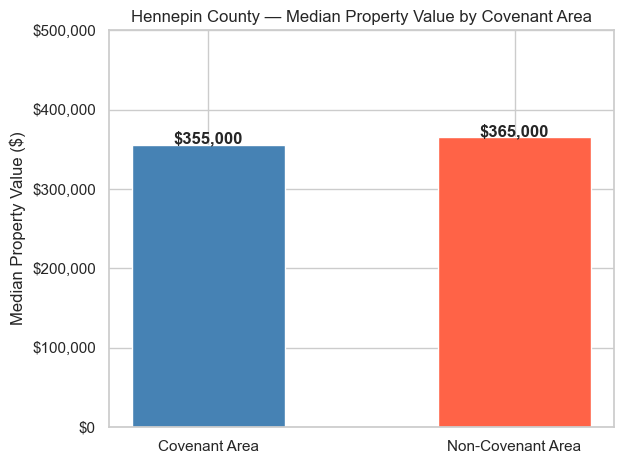

covenant_area
Covenant Area        355000.0
Non-Covenant Area    365000.0
Name: property_value, dtype: float64


In [27]:
prop_val = hennepin.groupby('covenant_area')['property_value'].median()

fig, ax = plt.subplots()
bars = ax.bar(prop_val.index, prop_val.values,
              color=['steelblue', 'tomato'], width=0.5)

for bar, val in zip(bars, prop_val.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2000,
            f'${val:,.0f}', ha='center',
            fontweight='bold', fontsize=12)

ax.set_title('Hennepin County — Median Property Value by Covenant Area')
ax.set_ylabel('Median Property Value ($)')
ax.set_ylim(0, 500000)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

print(prop_val)

Results:
- Covenant Area : median home value of $355,000.
- Non-Covenant Area: median property value of the area is 365,000.

Neighborhoods that are not covenant are a little more valued.
than covenant areas - the difference is 10000.

This appears to be unbelievable initially. However it is historically logical:
Wealthy neighborhoods placed the racial covenants to retain them.
minority residents OUT. Those regions accumulated riches throughout decades.
only open to white residents.

Non-covenant areas of Hennepin County, however, also have newer.
suburbs which have been increasing in value with time- which is the reason why
they creep a step to-day higher.

This is biased data since the whole property of Hennepin County.
market was conditioned by the decades of racial exclusion. The $10,000
gap indicates that history - not equal opportunity.

#### Chart 2 - Minority Population

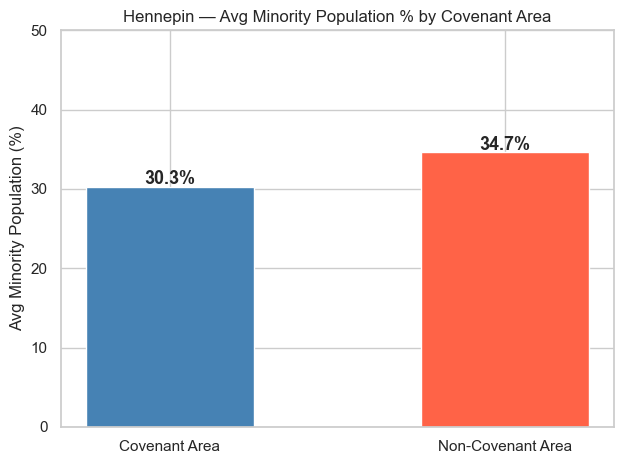

covenant_area
Covenant Area        30.307361
Non-Covenant Area    34.675565
Name: tract_minority_population_percent, dtype: float64


In [21]:
min_pop = hennepin.groupby('covenant_area')[
    'tract_minority_population_percent'].mean()

fig, ax = plt.subplots()
bars = ax.bar(min_pop.index, min_pop.values,
              color=['steelblue','tomato'], width=0.5)

for bar, val in zip(bars, min_pop.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center',
            fontweight='bold', fontsize=13)

ax.set_title('Hennepin — Avg Minority Population % by Covenant Area')
ax.set_ylabel('Avg Minority Population (%)')
ax.set_ylim(0, 50)
plt.tight_layout()
plt.show()

print(min_pop)

Results:
- Covenant Area (), 30.3% average minority population.
- Non-Covenant Area: The average minority population is 34.7% in this area.

In the current neighborhoods, covenants have reduced minority population.
than non-covenant areas - difference of 4.4 percentage points.

This is a clear indication of biasness in data. Covenants were designed
to keep minorities residents out of some neighborhoods.
Such regions were white and affluent. Minority
instead, residents were forced out of non-covenant areas instead.
that even in 2023, that pattern of segregation is apparent, more.
more than 50 years since it was made illegal to make covenants.

### Part B - Algorithmic Bias
#### Chart 3 - Approval by Minority %

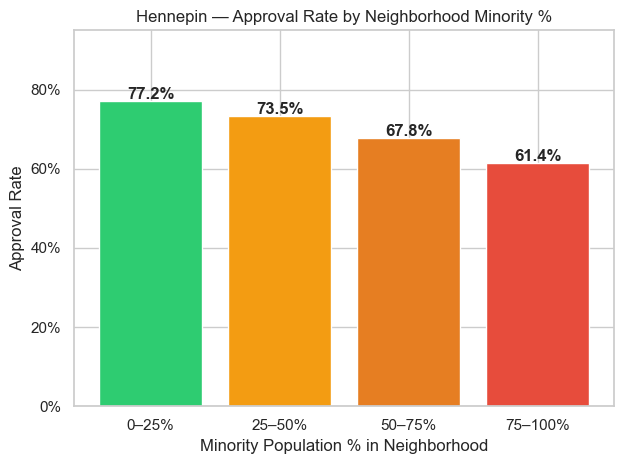

In [22]:
hennepin['minority_group'] = pd.cut(
    hennepin['tract_minority_population_percent'],
    bins=[0, 25, 50, 75, 100],
    labels=['0–25%', '25–50%', '50–75%', '75–100%']
)

minority_approval = hennepin.groupby(
    'minority_group', observed=True)['was_approved'].mean()

fig, ax = plt.subplots()
bars = ax.bar(minority_approval.index, minority_approval.values,
              color=['#2ecc71','#f39c12','#e67e22','#e74c3c'])

for bar, val in zip(bars, minority_approval.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.1%}', ha='center',
            fontweight='bold', fontsize=12)

ax.set_title('Hennepin — Approval Rate by Neighborhood Minority %')
ax.set_xlabel('Minority Population % in Neighborhood')
ax.set_ylabel('Approval Rate')
ax.set_ylim(0, 0.95)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show() 

Results:
- 0-25% minority neighbourhoods : 77.2% approved.
- 25-50% minority neighbourhoods: 73.5% approved.
- 50-75% minority neighborhoods 67.8% approved.
- 75-100% minorities neighborhoods: 61.4% approved.

This is a 15.8 percentage point decline of the most white.
to the very least-accessible quarters of the city - a evident and uniform
pattern of algorithmic bias.

Mortgage algorithm does not involve race per se. But it
uses property values and neighborhood income which were
molded through years of segregation. The result is applicants
in more diverse neighbourhoods are less likely to be systematically.
just to be accepted due to the location of their residence.

#### Chart 4 - Approval by Race

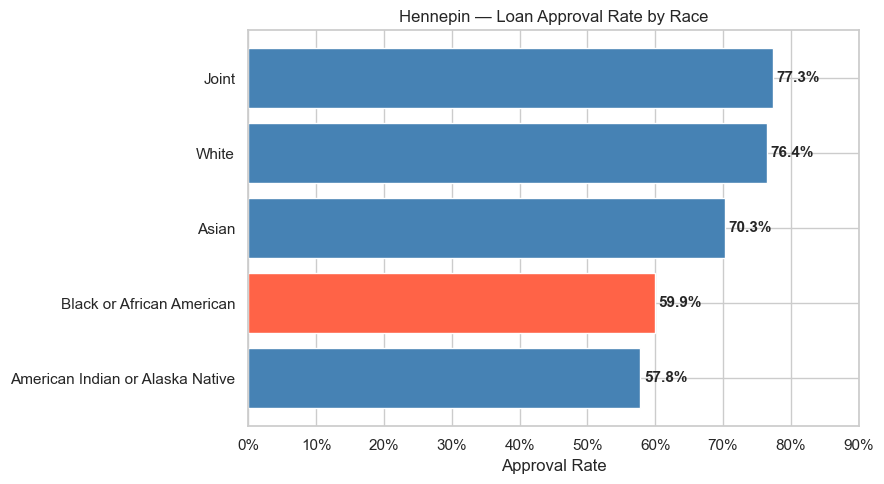

White approval rate : 76.4%
Black approval rate : 59.9%
Gap                 : 16.5%


In [23]:
main_races = ['White', 'Asian', 'Black or African American',
              'American Indian or Alaska Native', 'Joint']

race_df = hennepin[hennepin['derived_race'].isin(main_races)]
race_approval = race_df.groupby(
    'derived_race')['was_approved'].mean().sort_values()

colors = ['tomato' if r == 'Black or African American'
          else 'steelblue' for r in race_approval.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(race_approval.index, race_approval.values,
               color=colors)

for bar, val in zip(bars, race_approval.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center',
            fontweight='bold', fontsize=11)

ax.set_title('Hennepin — Loan Approval Rate by Race')
ax.set_xlabel('Approval Rate')
ax.set_xlim(0, 0.9)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

gap = race_approval['White'] - race_approval['Black or African American']
print(f"White approval rate : {race_approval['White']:.1%}")
print(f"Black approval rate : {race_approval['Black or African American']:.1%}")
print(f"Gap                 : {gap:.1%}")

Results:
- Joint applicants : 77.3%
- White applicants : 76.4%
- Asian applicants : 70.3%
- Black or African American : 59.9%
- American Indian or Alaska Native: 57.8 percent.

The difference between White (76.4) and Black (59.9) applicants
is 16.5 percentage points - the most significant finding in.
this analysis.

Only an approximate of 78 Black applicants are given the green light, compared to every 100 Whites applicants.
applicants are approved. The algorithm takes into account income, property.
value and neighborhood information- everything influenced by past.
discrimination-- and recreates racial by default.
Inequality in 2023 lending decisions.

### Chart 5 - Combined Bias: Race Inside Covenant Areas Only


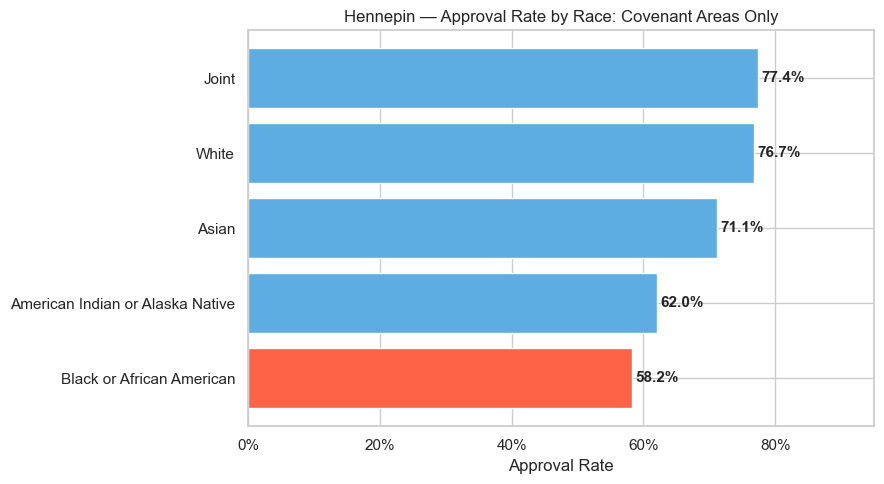

White approval in covenant areas : 76.7%
Black approval in covenant areas : 58.2%
Gap inside covenant areas        : 18.5%


In [24]:
covenant_df = hennepin[
    (hennepin['covenant_area'] == 'Covenant Area') &
    (hennepin['derived_race'].isin(main_races))]

race_cov = covenant_df.groupby(
    'derived_race')['was_approved'].mean().sort_values()

colors = ['tomato' if r == 'Black or African American'
          else '#5dade2' for r in race_cov.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(race_cov.index, race_cov.values, color=colors)

for bar, val in zip(bars, race_cov.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center',
            fontweight='bold', fontsize=11)

ax.set_title('Hennepin — Approval Rate by Race: Covenant Areas Only')
ax.set_xlabel('Approval Rate')
ax.set_xlim(0, 0.95)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

gap2 = race_cov['White'] - race_cov['Black or African American']
print(f"White approval in covenant areas : {race_cov['White']:.1%}")
print(f"Black approval in covenant areas : {race_cov['Black or African American']:.1%}")
print(f"Gap inside covenant areas        : {gap2:.1%}")

Results:
- White applicants : 76.7%
- Asian applicants : 71.1%
- American Indian or Alaska Native: 62.0%
- Black or African American : 58.2%
- Gap (White vs Black) : 18.5%

This chart will only zoom in covenant neighborhoods and question:
is there even any racial gap between people?
in the SAME discriminated neighborhood in the past?

The response to this question is YES, and the disparity is even greater here (18.5%)
than for the entire County of Hennepin (16.5% in Chart 4).

This is the most significant conclusion of the analysis. Black
applicants within the area of covenants have been doubly disadvantaged:
1. DATA BIAS - residing in neighborhoods that were formed due to history.
discrimination and inequitable economic status.
2. ALGORITHMIC BIAS -- approval pending yet at a much.
reduced level as compared to White applicants in the very same.
neighborhood

Both prejudices ply one above another - historical.
discrimination predetermined the situation, and the contemporary algorithm.
makes them worse.

## Ramsey County Extension

### Load state_MN.csv 

In [25]:
mn_hmda_raw = pd.read_csv("C:/Users/surpa/Downloads/state_MN.csv",
                           low_memory=False)

print(f"Minnesota HMDA shape: {mn_hmda_raw.shape}")
mn_hmda_raw.head()

Minnesota HMDA shape: (175162, 99)


,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,derived_race,derived_sex,action_taken,purchaser_type,preapproval,loan_type,loan_purpose,lien_status,reverse_mortgage,open-end_line_of_credit,business_or_commercial_purpose,loan_amount,loan_to_value_ratio,interest_rate,rate_spread,hoepa_status,total_loan_costs,total_points_and_fees,origination_charges,discount_points,lender_credits,loan_term,prepayment_penalty_term,intro_rate_period,negative_amortization,interest_only_payment,balloon_payment,other_nonamortizing_features,property_value,construction_method,occupancy_type,manufactured_home_secured_property_type,manufactured_home_land_property_interest,total_units,multifamily_affordable_units,income,debt_to_income_ratio,applicant_credit_score_type,co-applicant_credit_score_type,applicant_ethnicity-1,applicant_ethnicity-2,applicant_ethnicity-3,applicant_ethnicity-4,applicant_ethnicity-5,co-applicant_ethnicity-1,co-applicant_ethnicity-2,co-applicant_ethnicity-3,co-applicant_ethnicity-4,co-applicant_ethnicity-5,applicant_ethnicity_observed,co-applicant_ethnicity_observed,applicant_race-1,applicant_race-2,applicant_race-3,applicant_race-4,applicant_race-5,co-applicant_race-1,co-applicant_race-2,co-applicant_race-3,co-applicant_race-4,co-applicant_race-5,applicant_race_observed,co-applicant_race_observed,applicant_sex,co-applicant_sex,applicant_sex_observed,co-applicant_sex_observed,applicant_age,co-applicant_age,applicant_age_above_62,co-applicant_age_above_62,submission_of_application,initially_payable_to_institution,aus-1,aus-2,aus-3,aus-4,aus-5,denial_reason-1,denial_reason-2,denial_reason-3,denial_reason-4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,2023,549300VZVN841I2ILS84,33460,MN,27053.0,2.705302e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,Race Not Available,Male,1,2,2,2,1,1,2,2,2,305000.0,95.00000,6.500,0.576,2,16722.90,NaN,8821.90,7231.90,40.80,360,NaN,NaN,2,2,2,2,325000,1,1,3,5,1,NaN,65.0,46,3,10,3.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,2,4,6.0,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,2,4,1,5,2,4,<25,9999,No,NaN,1,1,3,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,4342,38.48,124300,83.64,1444,1506,62
1,2023,549300VZVN841I2ILS84,33460,MN,27003.0,2.700305e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,Male,1,1,1,1,1,1,2,2,2,285000.0,97.00000,6.450,0.375,2,9733.71,NaN,7225.71,5735.71,9.00,360,NaN,NaN,2,2,2,2,295000,1,1,3,5,1,NaN,72.0,41,1,10,2.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,2,4,5.0,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,2,4,1,5,2,4,<25,9999,No,NaN,1,1,1,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,3008,21.74,124300,86.21,965,1168,63
2,2023,549300VZVN841I2ILS84,33460,MN,27037.0,2.703706e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,Joint,1,3,2,1,1,1,2,2,2,365000.0,72.80000,7.490,0.890,2,4182.27,NaN,1555.52,65.52,575.00,360,NaN,NaN,2,2,2,2,505000,1,1,3,5,1,NaN,175.0,42,1,9,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,2,2,5.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,2,2,1,2,2,2,25-34,25-34,No,No,1,1,2,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,6341,18.62,124300,130.45,2012,2268,28
3,2023,549300VZVN841I2ILS84,33460,MN,27003.0,2.700305e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,Asian,Joint,1,6,2,1,1,1,2,2,2,315000.0,98.50700,7.000,0.458,2,6794.50,NaN,4610.00,NaN,39.00,360,NaN,NaN,2,2,2,2,335000,1,1,3,5,1,NaN,108.0,42,3,9,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,2,2,2.0,22.0,NaN,NaN,NaN,2.0,22.0,NaN,NaN,NaN,2,2,1,2,2,2,55-64,35-44,No,No,1,1,1,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,6769,22.37,124300,97.44,1574,1705,31
4,2023,549300VZVN841I2ILS84,99999,MN,27113.0,2.711309e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or 

In [26]:
# Check what loan types are in Ramsey
print("=== All loan types in Ramsey (before filter) ===")
ramsey_all = mn_hmda_raw[mn_hmda_raw["county_code"] == 27123].copy()
print(f"Total Ramsey rows (all loans) : {len(ramsey_all):,}")
print()
print("Loan purpose breakdown:")
print(ramsey_all["loan_purpose"].value_counts())
print()

# Loan purpose codes meaning:
loan_purpose_labels = {
    1: "Home purchase",
    2: "Home improvement", 
    3: "Refinancing",
    4: "Other purpose",
    5: "Cash-out refinancing",
    31: "Manufactured housing",
    32: "Manufactured housing"
}

for code, count in ramsey_all["loan_purpose"].value_counts().items():
    label = loan_purpose_labels.get(code, "Unknown")
    print(f"  {code} = {label} : {count:,} rows")

print()
print("=== After filtering home purchase only (loan_purpose == 1) ===")
ramsey_home = ramsey_all[ramsey_all["loan_purpose"] == 1]
print(f"Home purchase only rows : {len(ramsey_home):,}")

=== All loan types in Ramsey (before filter) ===
Total Ramsey rows (all loans) : 14,481

Loan purpose breakdown:
loan_purpose
1     8793
2     1861
4     1694
32    1239
31     860
5       34
Name: count, dtype: int64

  1 = Home purchase : 8,793 rows
  2 = Home improvement : 1,861 rows
  4 = Other purpose : 1,694 rows
  32 = Manufactured housing : 1,239 rows
  31 = Manufactured housing : 860 rows
  5 = Cash-out refinancing : 34 rows

=== After filtering home purchase only (loan_purpose == 1) ===
Home purchase only rows : 8,793


### Filter and Clean Ramsey

In [23]:
# Filter Ramsey County
ramsey = mn_hmda_raw[mn_hmda_raw["county_code"] == 27123].copy()

# Filter home purchase loans only (same as Hennepin)
ramsey = ramsey[ramsey["loan_purpose"] == 1].copy()

# Keep only needed columns
ramsey_cols = [
    "census_tract",
    "derived_race",
    "action_taken",
    "loan_amount",
    "property_value",
    "income",
    "interest_rate",
    "tract_minority_population_percent",
    "tract_to_msa_income_percentage",
    "denial_reason-1"
]
ramsey = ramsey[ramsey_cols].copy()

# Remove unknown race
exclude_races = ['Race Not Available', 'Free Form Text Only']
ramsey = ramsey[~ramsey["derived_race"].isin(exclude_races)].copy()

# Convert numeric columns
for col in ["loan_amount", "property_value", "income",
            "interest_rate", "tract_minority_population_percent",
            "tract_to_msa_income_percentage"]:
    ramsey[col] = pd.to_numeric(ramsey[col], errors="coerce")

# Create was_approved column
ramsey["was_approved"] = ramsey["action_taken"].isin([1, 2])

# Add minority group column
ramsey['minority_group'] = pd.cut(
    ramsey['tract_minority_population_percent'],
    bins=[0, 25, 50, 75, 100],
    labels=['0–25%', '25–50%', '50–75%', '75–100%']
)

print("Ramsey County shape:", ramsey.shape)
print()
print("=== Ramsey Summary ===")
print(f"Total rows     : {len(ramsey):,}")
print(f"Approval rate  : {ramsey['was_approved'].mean():.1%}")
print()
print("=== Race of Applicants ===")
print(ramsey['derived_race'].value_counts())

Ramsey County shape: (6710, 12)

=== Ramsey Summary ===
Total rows     : 6,710
Approval rate  : 71.7%

=== Race of Applicants ===
derived_race
White                                        4679
Asian                                        1087
Black or African American                     604
Joint                                         247
American Indian or Alaska Native               72
2 or more minority races                       14
Native Hawaiian or Other Pacific Islander       7
Name: count, dtype: int64


### Part A Data Bias - Chart 1: Property value

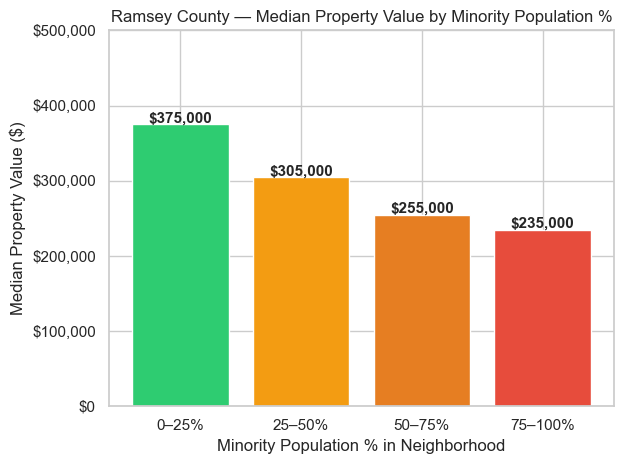

minority_group
0–25%      375000.0
25–50%     305000.0
50–75%     255000.0
75–100%    235000.0
Name: property_value, dtype: float64


In [24]:
prop_val_r = ramsey.groupby(
    'minority_group', observed=True)['property_value'].median()

fig, ax = plt.subplots()
bars = ax.bar(prop_val_r.index, prop_val_r.values,
              color=['#2ecc71','#f39c12','#e67e22','#e74c3c'])

for bar, val in zip(bars, prop_val_r.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2000,
            f'${val:,.0f}', ha='center',
            fontweight='bold', fontsize=11)

ax.set_title('Ramsey County — Median Property Value by Minority Population %')
ax.set_xlabel('Minority Population % in Neighborhood')
ax.set_ylabel('Median Property Value ($)')
ax.set_ylim(0, 500000)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()
print(prop_val_r)

Results:
- 0-25% minority neighborhoods : $375,000
  
- 25-50% minority neighborhoods : $305,000

  
- 50-75% minority neighborhoods : $255,000

  
- 75-100% minority neighborhoods : $235,000

There is a decrease of property values in the least to the most by a figure of 140,000.
neighborhoods in Ramsey County that are minorities. This is a much
more definite pattern than in Hennepin County, where covenant history.
complicated the comparison.

This is a good indication of bias in the data the neighborhoods with.
a greater number of minority populations possess much lower property.
values, which represents decades of unequal investment and
limited access to wealth-making.

### Part B - Algorithmic Bias
#### Chart 1 - Approval Rate by Neighborhood Minority %

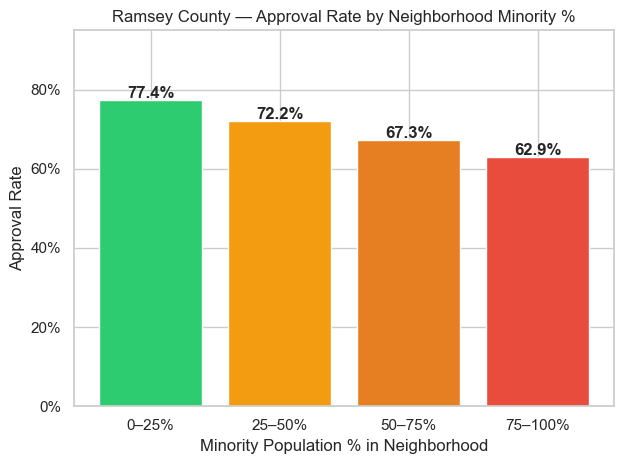

minority_group
0–25%      0.774474
25–50%     0.722054
50–75%     0.673267
75–100%    0.629087
Name: was_approved, dtype: float64


In [26]:
minority_approval_r = ramsey.groupby(
    'minority_group', observed=True)['was_approved'].mean()

fig, ax = plt.subplots()
bars = ax.bar(minority_approval_r.index,
              minority_approval_r.values,
              color=['#2ecc71','#f39c12','#e67e22','#e74c3c'])

for bar, val in zip(bars, minority_approval_r.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.1%}', ha='center',
            fontweight='bold', fontsize=12)

ax.set_title('Ramsey County — Approval Rate by Neighborhood Minority %')
ax.set_xlabel('Minority Population % in Neighborhood')
ax.set_ylabel('Approval Rate')
ax.set_ylim(0, 0.95)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()
print(minority_approval_r)

Results:
- 0-25% minority neighborhoods 77.4% approved.
- 25-50 percent minority neighborhoods: 72.2% yes.
- 50-75% minority neighbourhoods: 67.3% approved.
- 75-100% minorities neighborhoods: 62.9% approved.

A definite decrease of 14.5 percentage points in the least to the most.
minority neighborhoods. This mirrors the exact same
pattern occurring in Hennepin County (15.8% drop), affirming.
that there is an algorithmic bias in both counties.

Income in the neighborhood and mortgage algorithm utilize income in the neighborhood.
values of property as inputs - shaped by history
segregation - and generates less approval by default.
prices in less homogeneous neighborhoods.

### Chart 2 - Approval Rate by Race

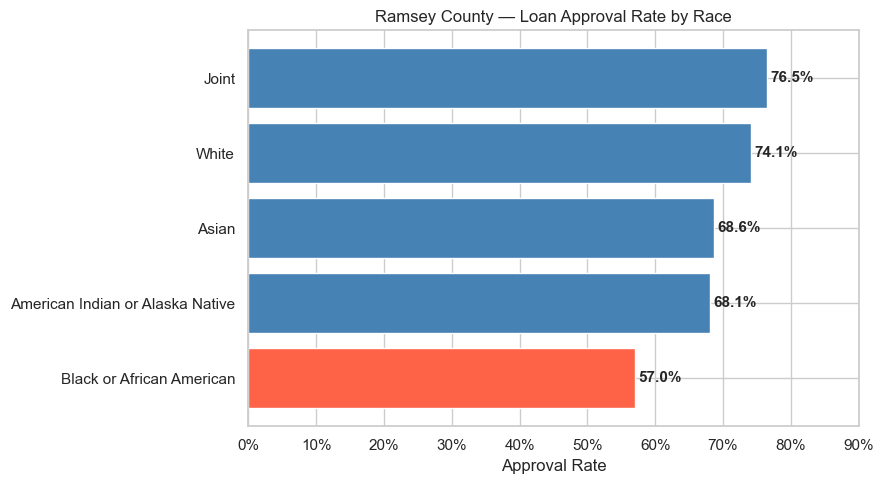

White approval rate : 74.1%
Black approval rate : 57.0%
Gap                 : 17.1%


In [27]:
main_races = ['White', 'Asian', 'Black or African American',
              'American Indian or Alaska Native', 'Joint']

race_df_r = ramsey[ramsey['derived_race'].isin(main_races)]
race_approval_r = race_df_r.groupby(
    'derived_race')['was_approved'].mean().sort_values()

colors = ['tomato' if r == 'Black or African American'
          else 'steelblue' for r in race_approval_r.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(race_approval_r.index,
               race_approval_r.values, color=colors)

for bar, val in zip(bars, race_approval_r.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center',
            fontweight='bold', fontsize=11)

ax.set_title('Ramsey County — Loan Approval Rate by Race')
ax.set_xlabel('Approval Rate')
ax.set_xlim(0, 0.9)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

gap_r = (race_approval_r['White'] -
         race_approval_r['Black or African American'])
print(f"White approval rate : {race_approval_r['White']:.1%}")
print(f"Black approval rate : {race_approval_r['Black or African American']:.1%}")
print(f"Gap                 : {gap_r:.1%}")

Results:
- Joint applicants : 76.5%
- White applicants : 74.1%
- Asian applicants : 68.6%
- American Indian or Alaska Native: 68.1%
- Black or African American : 57.0%
- Gap (White vs Black) : 17.1%

African Americans or blacks who are applicants in Ramsey County.
are only sanctioned at 57.0% - - vs. 74.1% on
White applicants. This 17.1 percentage point gap is
the greatest observation of the Ramsey analysis.

In comparison with Hennepin County:
- Hennepin White-Black gap : 16.5%
- Ramsey White-Black gap : 17.1%

The disparity is in fact even larger in Ramsey than Hennepin.
This demonstrates that there is racial inequality in the provision of mortgages.
is not peculiar to a single county - it is a uniform
systemic pattern throughout the whole Minneapolis-Saint.
Paul metro area.

The algorithm does not specifically refer to race. But through
neighborhood income and property are proxy variables.
values - historical discrimination has molded both of you.
it forever brings worse results to Black.
applicants in both counties.
This line chart follows rates of approvals in 10 details.
Minority population groups in Ramsey County.

### Chart 3 - Approval Rate vs Minority % (tract level)

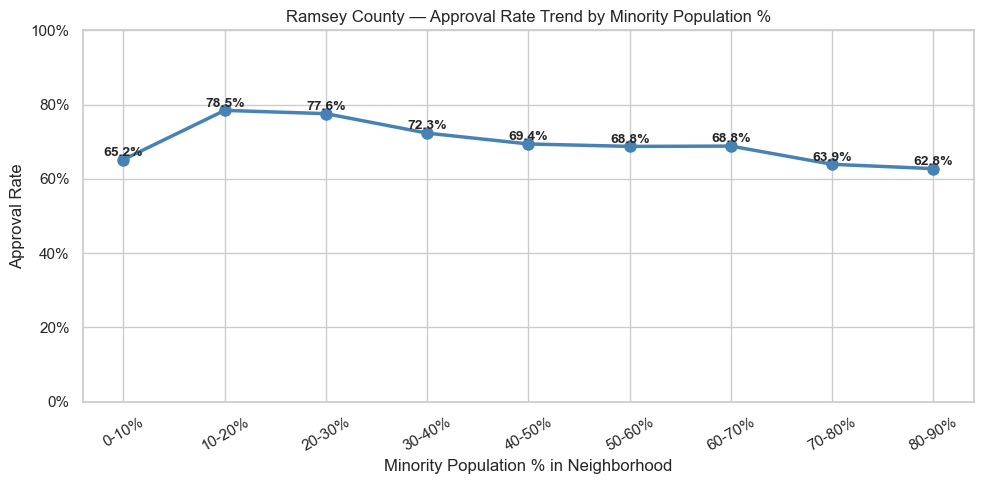

In [34]:
ramsey_by_tract = ramsey.groupby(
    'census_tract', as_index=False).agg(
    tract_minority_population_percent=(
        'tract_minority_population_percent', 'median'),
    approval_rate=('was_approved', 'mean')
)

# Bin into groups for cleaner line chart
ramsey_by_tract['minority_bin'] = pd.cut(
    ramsey_by_tract['tract_minority_population_percent'],
    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    labels=['0-10%','10-20%','20-30%','30-40%','40-50%',
            '50-60%','60-70%','70-80%','80-90%','90-100%']
)

line_data = ramsey_by_tract.groupby(
    'minority_bin', observed=True)['approval_rate'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(line_data.index, line_data.values,
        color='steelblue', linewidth=2.5,
        marker='o', markersize=8)

for i, (x, y) in enumerate(zip(line_data.index, line_data.values)):
    ax.text(i, y + 0.01, f'{y:.1%}',
            ha='center', fontweight='bold', fontsize=10)

ax.set_title('Ramsey County — Approval Rate Trend by Minority Population %')
ax.set_xlabel('Minority Population % in Neighborhood')
ax.set_ylabel('Approval Rate')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Results:
- 0-10% minority neighborhoods : 65.2%
- 10-20% minority neighbourhoods: 78.5% (maximum)
- 20-30% minority neighborhoods : 77.6%
- 30-40% minority neighborhoods : 72.3%
- 40-50% minority neighborhoods : 69.4%
- 50-60% minority neighborhoods : 68.8%
- 60-70% minority neighborhoods : 68.8%
- 70-80% minority neighborhoods : 63.9%
- 80-90% minority neighborhoods : 62.8%

An interesting pattern is seen on the chart -- approval rates
maximum at 10-20% minority (78.5%) followed by a steady decline.
beyond that, as there is a further growth in minority population.

Since the peak to the most minority neighborhoods the
drop is 15.7 percentage points (78.5% - 62.8%). This
It is obvious that there is a steady downward trend in the second half of the chart.
evidence of algorithmic biasing - as neighborhoods become.
more different, the approval rates are always decreased.

The minimal increase at the beginning (0-10 percent to 10-20 percent) is indicative of.
that other economic may be present in other areas of the low-minority.
circumstances influencing approvals. But the overall downward
trend since 20 per cent. gives the true history of it.
algorithm is more discriminatory of applicants.
neighborhoods consistently.

## County Comparison

In [35]:
# County comparison table
hennepin_summary = pd.DataFrame({
    'Total Applications'      : [len(hennepin)],
    'Overall Approval Rate'   : [f"{hennepin['was_approved'].mean():.1%}"],
    'Median Property Value'   : [f"${hennepin['property_value'].median():,.0f}"],
    'Median Income'           : [f"${hennepin['income'].median():,.0f}k"],
    'Median Interest Rate'    : [f"{hennepin['interest_rate'].median():.2f}%"],
    'Median Minority %'       : [f"{hennepin['tract_minority_population_percent'].median():.1f}%"],
    'White Approval Rate'     : [f"{race_approval['White']:.1%}"],
    'Black Approval Rate'     : [f"{race_approval['Black or African American']:.1%}"],
    'White-Black Gap'         : [f"{gap:.1%}"]
}, index=['Hennepin County'])

ramsey_summary = pd.DataFrame({
    'Total Applications'      : [len(ramsey)],
    'Overall Approval Rate'   : [f"{ramsey['was_approved'].mean():.1%}"],
    'Median Property Value'   : [f"${ramsey['property_value'].median():,.0f}"],
    'Median Income'           : [f"${ramsey['income'].median():,.0f}k"],
    'Median Interest Rate'    : [f"{ramsey['interest_rate'].median():.2f}%"],
    'Median Minority %'       : [f"{ramsey['tract_minority_population_percent'].median():.1f}%"],
    'White Approval Rate'     : [f"{race_approval_r['White']:.1%}"],
    'Black Approval Rate'     : [f"{race_approval_r['Black or African American']:.1%}"],
    'White-Black Gap'         : [f"{gap_r:.1%}"]
}, index=['Ramsey County'])

comparison_table = pd.concat([hennepin_summary, ramsey_summary])
display(comparison_table.T) 

,Hennepin County,Ramsey County
Total Applications,17059,6710
Overall Approval Rate,74.0%,71.7%
Median Property Value,"$355,000","$295,000"
Median Income,$112k,$87k
Median Interest Rate,6.62%,6.75%
Median Minority %,25.9%,36.5%
White Approval Rate,76.4%,74.1%
Black Approval Rate,59.9%,57.0%
White-Black Gap,16.5%,17.1%


### Comparison Table of the Counties - Major Results.

This table is a comparison of Hennepin and Ramsey County regarding
all major indicators of our analysis.

Key observations:

APPLICATIONS & APPROVAL:
- Hennepin has a higher number of applications (17,059 vs 6,710)
- Hennepin has more overall approval rate.
(74.0 per cent vs 71.7) - a difference of 2.3 percentage points.

PROPERTY & INCOME:
- Hennepin is more expensive in terms of property values.
($355,000 vs $295,000) -- a $60,000 difference
- Hennepin is above average median income (112k vs 87k).
- This implies that Ramsey County neighborhoods are.
was usually poorer than Hennepin.

DEMOGRAPHICS:
- Ramsey consists of a greater median minority population.
(36.5% vs 25.9%) -- 10.6 percentage points higher
- This is the reason why the property values in Ramsey are lower.
and income - representing past trends of
minority residents concentrated less.
wealthy areas

RACIAL GAP - MOST IMPORTANT:
- Hennepin White-Black gap : 16.5%
- Ramsey White-Black gap : 17.1%
- The difference is broader in Ramsey even though it is a
various county of different natures.

CONCLUSION FROM TABLE:
The same situation can be observed in both counties - White applicants.
are passed at much greater rates than Black.
applicants irrespective of county. The racial gap is
uniform (16-17%) in the two counties, demonstrating.
this is an institutional problem in the mortgage lending.
system - not a local anomaly.
